<a href="https://colab.research.google.com/github/anwarzahid8284/python_practice/blob/main/brain%20tumor%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git config --global user.email "anwarzahid.bcs@gmail.com"
!git config --global user.name "Anwar Zahid"

In [ ]:
%cd /content/Brain-tumor-classification-

[Errno 2] No such file or directory: '/content/Brain-tumor-classification-'
/content


In [1]:
pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.5 MB/s eta 0:00:00


In [ ]:
!ls


sample_data


In [ ]:
!echo "# Brain Tumor Classification" > README.md


In [ ]:
!cp https://colab.research.google.com/drive/1-hSIFHermV5FjwZZZLanoFTmHspgGh_Y?usp=drive_link


cp: missing destination file operand after 'https://colab.research.google.com/drive/1-hSIFHermV5FjwZZZLanoFTmHspgGh_Y?usp=drive_link'
Try 'cp --help' for more information.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
import cv2
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# from google.colab import files
# uploaded = files.upload()

In [ ]:
import os
import zipfile

file_path = os.path.join(os.getcwd(), '/content/drive/MyDrive/archive.zip')  # Get absolute path using os.getcwd()
z = zipfile.ZipFile(file_path)
z.extractall()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/archive.zip'

In [ ]:
#----------------------Renaming File---------------#

folder = 'brain_tumor_dataset/yes/'
count = 1

for filename in os.listdir(folder):
    source = folder + filename
    destination = folder + "Y_" +str(count)+".jpg"
    os.rename(source, destination)
    count+=1
print("All files are renamed in the yes dir.")

All files are renamed in the yes dir.


In [ ]:
folder = 'brain_tumor_dataset/no/'
count = 1

for filename in os.listdir(folder):
    source = folder + filename
    destination = folder + "N_" +str(count)+".jpg"
    os.rename(source, destination)
    count+=1
print("All files are renamed in the no dir.")

All files are renamed in the no dir.


In [ ]:
# EDA(Exploratory Data Analysis)

In [ ]:
listyes = os.listdir("brain_tumor_dataset/yes/")
number_files_yes = len(listyes)
print(number_files_yes)

listno = os.listdir("brain_tumor_dataset/no/")
number_files_no = len(listno)
print(number_files_no)

155
98


In [ ]:
# Plot

In [ ]:
data = {'tumorous': number_files_yes, 'non-tumorous': number_files_no}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

NameError: name 'number_files_yes' is not defined

In [ ]:
# Data Augmentation
# 155(61%), 98(39%)
# imbalance

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,  # Rescale pixel values to [0, 1]
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)  # Just rescale for validation set

# If you use `train_datagen` for training, it will apply the augmentations automatically.
train_generator = train_datagen.flow_from_directory(
    'tumorous_and_nontumorous/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = valid_datagen.flow_from_directory(
    'tumorous_and_nontumorous/valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


FileNotFoundError: [Errno 2] No such file or directory: 'tumorous_and_nontumorous/train'

In [ ]:
def timing(sec_elapsed):
    h = int(sec_elapsed / (60*60))
    m = int(sec_elapsed % (60*60) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{s}"

In [ ]:
#------------Image Augmentation (rotation, flips, brightness adjustments)-------------------#

def augmented_data(file_dir, n_generated_samples, save_to_dir):
    data_gen = ImageDataGenerator(rotation_range=10,
                      width_shift_range=0.1,
                      height_shift_range=0.1,
                      shear_range=0.1,
                      brightness_range=(0.3, 1.0),
                      horizontal_flip=True,
                      vertical_flip=True,
                      fill_mode='nearest')
    for filename in os.listdir(file_dir):
        image = cv2.imread(file_dir + '/' + filename)
        image = image.reshape((1,) + image.shape)
        save_prefix = 'aug_' + filename[:-4]
        i=0
        for batch in data_gen.flow(x = image, batch_size = 1, save_to_dir = save_to_dir, save_prefix = save_prefix, save_format = "jpg"):
            i+=1
            if i>n_generated_samples:
                break

In [ ]:
import time
start_time = time.time()

yes_path = 'brain_tumor_dataset/yes/'
no_path = 'brain_tumor_dataset/no/'

augmented_data_path = 'brain_tumor_dataset/augmented_data/'

augmented_data(file_dir = yes_path, n_generated_samples=6, save_to_dir=augmented_data_path+'yes')
augmented_data(file_dir = no_path, n_generated_samples=9, save_to_dir=augmented_data_path+'no')

end_time = time.time()
execution_time = end_time - start_time
print(timing(execution_time))

0:1:26.517412185668945


In [ ]:
def data_summary(main_path):
    yes_path = "brain_tumor_dataset/augmented_data/yes/"
    no_path = "brain_tumor_dataset/augmented_data/no/"

    n_pos = len(os.listdir(yes_path))
    n_neg = len(os.listdir(no_path))

    n = (n_pos + n_neg)

    pos_per = (n_pos*100)/n
    neg_per = (n_neg*100)/n

    print(f"Number of sample: {n}")
    print(f"{n_pos} Number of positive sample in percentage: {pos_per}%")
    print(f"{n_neg} Number of negative sample in percentage: {neg_per}%")

In [ ]:
data_summary(augmented_data_path)

Number of sample: 2065
1085 Number of positive sample in percentage: 52.54237288135593%
980 Number of negative sample in percentage: 47.45762711864407%


In [ ]:
listyes = os.listdir("brain_tumor_dataset/augmented_data/yes/")
number_files_yes = len(listyes)
print(number_files_yes)

listno = os.listdir("brain_tumor_dataset/augmented_data/no/")
number_files_no = len(listno)
print(number_files_no)

1085
980


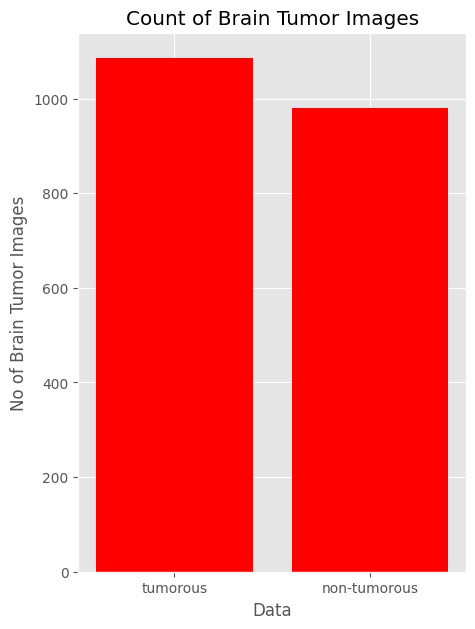

In [ ]:
data = {'tumorous': number_files_yes, 'non-tumorous': number_files_no}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

In [ ]:
# Data Preprocessing

In [ ]:
# Convert BGR TO GRAY
# GaussianBlur
# Threshold
# Erode
# Dilate
# Find Contours

In [ ]:
#-----------------Cropping Brain Tumor Regions-----------------#

import imutils
def crop_brain_tumor(image, plot=False):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # gray scale
    gray = cv2.GaussianBlur(gray, (5,5), 0) # remove blurness

    thres = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1] #conver turmor area to white and other black in image
    thres =cv2.erode(thres, None, iterations = 2) # remove white noise
    thres = cv2.dilate(thres, None, iterations = 2)

    cnts = cv2.findContours(thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key = cv2.contourArea)

    extLeft = tuple(c[c[:,:,0].argmin()][0])
    extRight = tuple(c[c[:,:,0].argmax()][0])
    extTop = tuple(c[c[:,:,1].argmin()][0])
    extBot = tuple(c[c[:,:,1].argmax()][0])

    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    if plot:
        plt.figure()
        plt.subplot(1, 2, 1)
        plt.imshow(image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Original Image')

        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Cropped Image')
        plt.show()
    return new_image


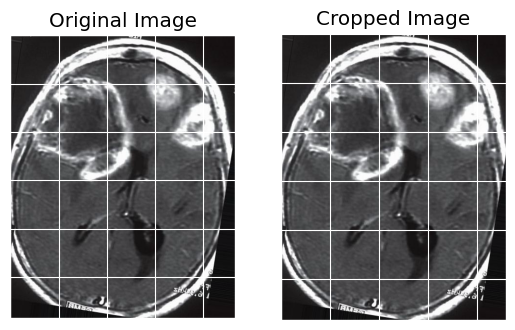

array([[[37, 35, 35],
        [37, 35, 35],
        [37, 35, 35],
        ...,
        [22, 17, 18],
        [22, 17, 18],
        [22, 17, 18]],

       [[30, 28, 28],
        [30, 28, 28],
        [31, 29, 29],
        ...,
        [22, 17, 18],
        [22, 17, 18],
        [22, 17, 18]],

       [[33, 31, 31],
        [33, 31, 31],
        [33, 31, 31],
        ...,
        [22, 17, 18],
        [22, 17, 18],
        [22, 17, 18]],

       ...,

       [[21, 19, 19],
        [21, 19, 19],
        [21, 19, 19],
        ...,
        [21, 16, 17],
        [21, 16, 17],
        [21, 16, 17]],

       [[21, 19, 19],
        [21, 19, 19],
        [21, 19, 19],
        ...,
        [21, 16, 17],
        [21, 16, 17],
        [21, 16, 17]],

       [[20, 18, 18],
        [20, 18, 18],
        [20, 18, 18],
        ...,
        [20, 15, 16],
        [20, 15, 16],
        [20, 15, 16]]], dtype=uint8)
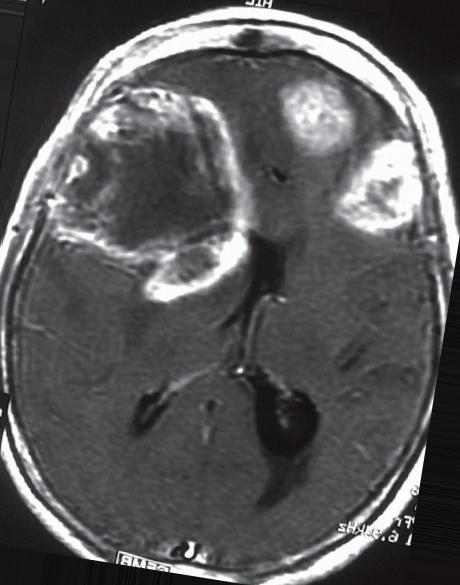

In [ ]:
img = cv2.imread('/content/brain_tumor_dataset/augmented_data/yes/aug_Y_100_0_1774.jpg')  # Update with correct path
crop_brain_tumor(img, True)

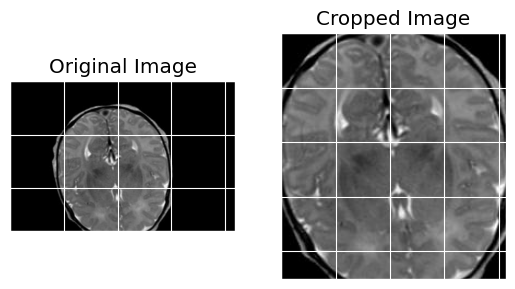

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
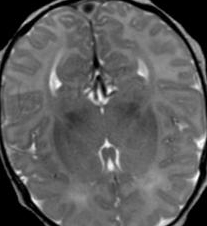

In [ ]:
img = cv2.imread('/content/brain_tumor_dataset/augmented_data/no/aug_N_10_0_1173.jpg')
crop_brain_tumor(img, True)

In [ ]:
folder1 = 'brain_tumor_dataset/augmented_data/no/'
folder2 = 'brain_tumor_dataset/augmented_data/yes/'

for filename in os.listdir(folder1):
    img = cv2.imread(folder1 + filename)
    img = crop_brain_tumor(img, False)
    cv2.imwrite(folder1 + filename, img)
for filename in os.listdir(folder2):
    img = cv2.imread(folder2 + filename)
    img = crop_brain_tumor(img, False)
    cv2.imwrite(folder2 + filename, img)

In [ ]:
# image loading

In [ ]:
from sklearn.utils import shuffle
def load_data(dir_list, image_size):
    X=[]
    y=[]

    image_width, image_height=image_size

    for directory in dir_list:
        for filename in os.listdir(directory):
            image = cv2.imread(directory + '/' + filename)
            image = crop_brain_tumor(image, plot=False)
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation = cv2.INTER_CUBIC)
            image = image/255.00
            X.append(image)
            if directory[-3:] == "yes":
                y.append(1)
            else:
                y.append(0)
    X=np.array(X)
    y=np.array(y)

    X,y = shuffle(X,y)
    print(f"Number of example is : {len(X)}")
    print(f"X SHAPE is : {X.shape}")
    print(f"y SHAPE is : {y.shape}")
    return X,y


In [ ]:
augmented_path = 'brain_tumor_dataset/augmented_data/'
augmeneted_yes = augmented_path + 'yes'
augmeneted_no = augmented_path + 'no'

IMAGE_WIDTH, IMAGE_HEIGHT = (224,224)

X,y = load_data([augmeneted_yes, augmeneted_no], (IMAGE_WIDTH, IMAGE_HEIGHT))

Number of example is : 2065
X SHAPE is : (2065, 224, 224, 3)
y SHAPE is : (2065,)


In [ ]:
def plot_sample_images(X, y, n=50):

    for label in [0,1]:
        images = X[np.argwhere(y == label)]
        n_images = images[:n]

        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))

        i = 1
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])

            plt.tick_params(axis='both', which='both',
                            top=False, bottom=False, left=False, right=False,
                            labelbottom=False, labeltop=False, labelleft=False,
                            labelright=False)

            i += 1

        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

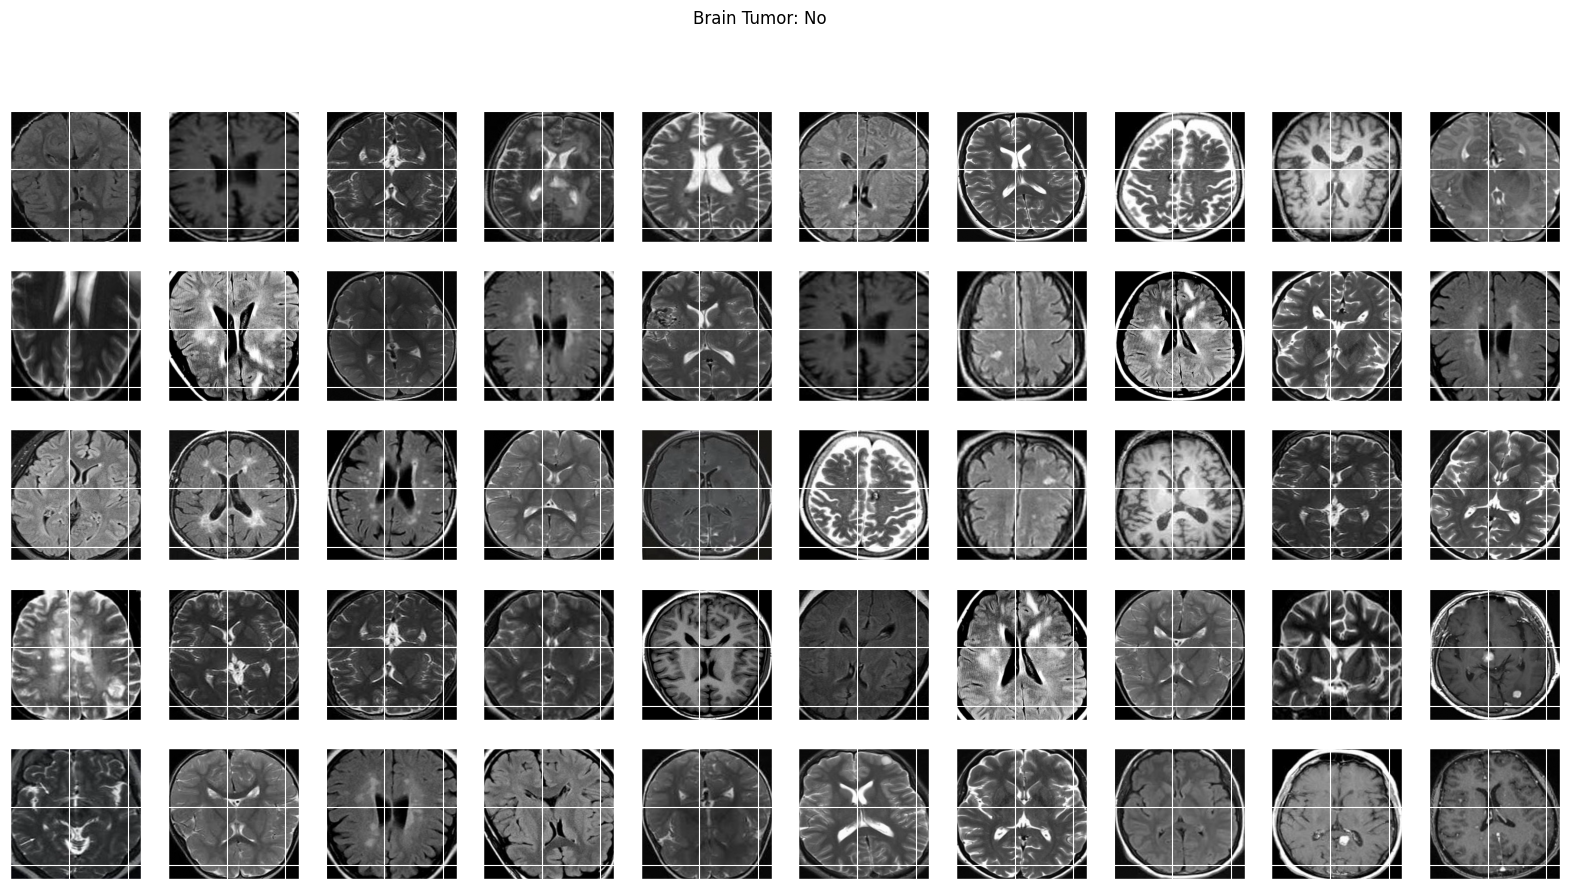

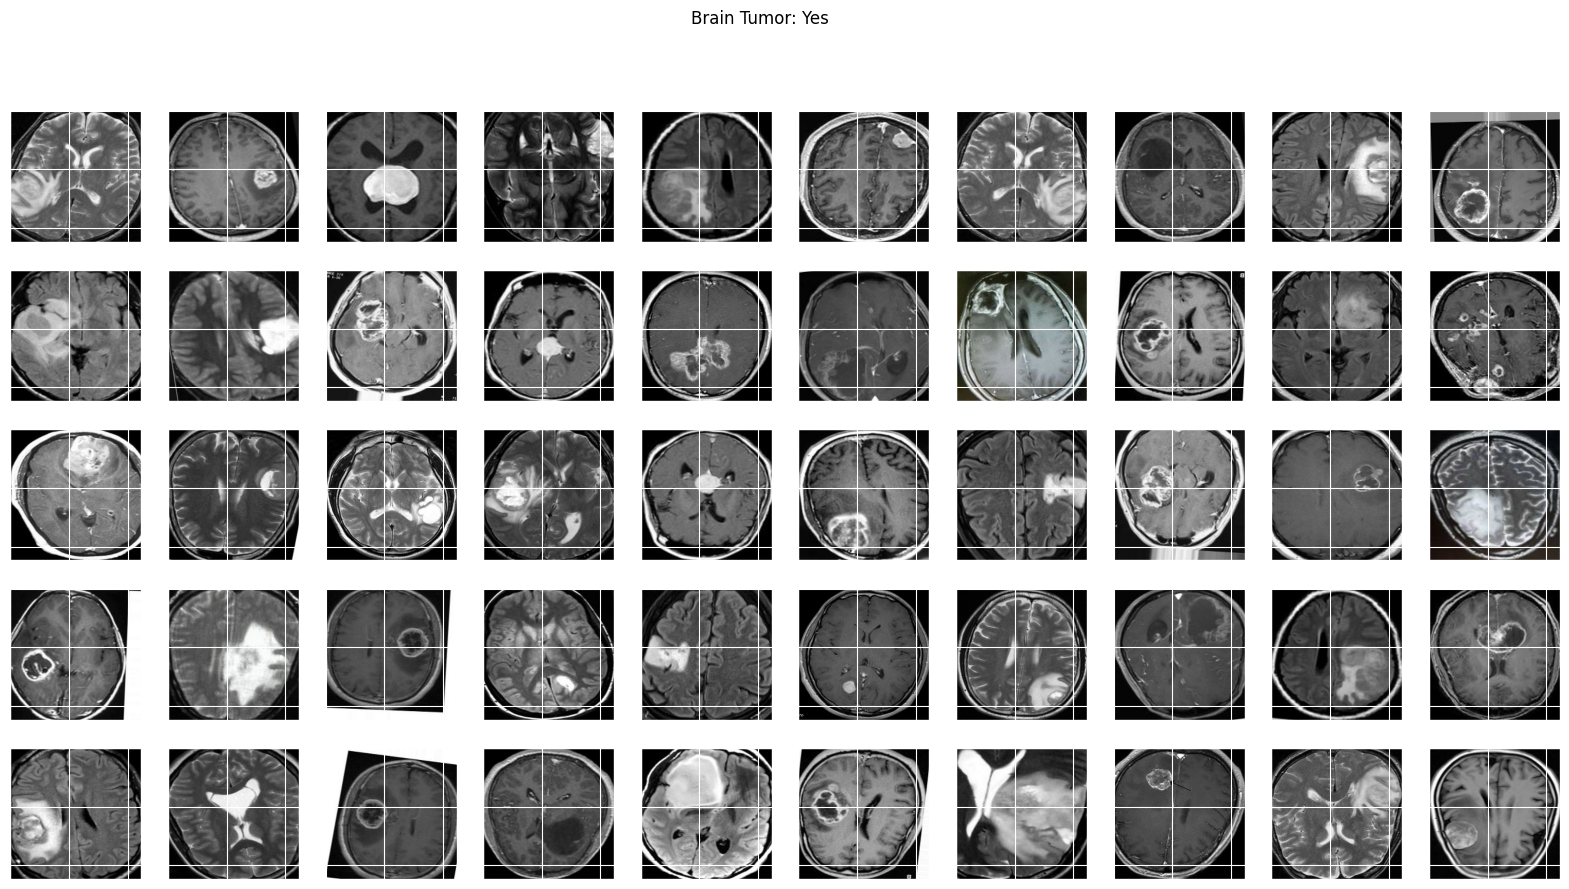

In [ ]:
plot_sample_images(X,y)

In [ ]:
# Data Spliting
# Train
# Test
# Validation

In [ ]:
if not os.path.isdir('tumorous_and_nontumorous'):
    base_dir = 'tumorous_and_nontumorous'
    os.mkdir(base_dir)

In [ ]:
if not os.path.isdir('tumorous_and_nontumorous/train'):
    train_dir = os.path.join(base_dir , 'train')
    os.mkdir(train_dir)
if not os.path.isdir('tumorous_and_nontumorous/test'):
    test_dir = os.path.join(base_dir , 'test')
    os.mkdir(test_dir)
if not os.path.isdir('tumorous_and_nontumorous/valid'):
    valid_dir = os.path.join(base_dir , 'valid')
    os.mkdir(valid_dir)

In [ ]:
if not os.path.isdir('tumorous_and_nontumorous/train/tumorous'):
    infected_train_dir = os.path.join(train_dir, 'tumorous')
    os.mkdir(infected_train_dir)
if not os.path.isdir('tumorous_and_nontumorous/test/tumorous'):
    infected_test_dir = os.path.join(test_dir, 'tumorous')
    os.mkdir(infected_test_dir)
if not os.path.isdir('tumorous_and_nontumorous/valid/tumorous'):
    infected_valid_dir = os.path.join(valid_dir, 'tumorous')
    os.mkdir(infected_valid_dir)

In [ ]:
if not os.path.isdir('tumorous_and_nontumorous/train/nontumorous'):
    healthy_train_dir = os.path.join(train_dir, 'nontumorous')
    os.mkdir(healthy_train_dir)
if not os.path.isdir('tumorous_and_nontumorous/test/nontumorous'):
    healthy_test_dir = os.path.join(test_dir, 'nontumorous')
    os.mkdir(healthy_test_dir)
if not os.path.isdir('tumorous_and_nontumorous/valid/nontumorous'):
    healthy_valid_dir = os.path.join(valid_dir, 'nontumorous')
    os.mkdir(healthy_valid_dir)

In [ ]:
original_dataset_tumorours = os.path.join('brain_tumor_dataset/augmented_data','yes/')
original_dataset_nontumorours = os.path.join('brain_tumor_dataset/augmented_data','no/')

In [ ]:
files = os.listdir('brain_tumor_dataset/augmented_data/yes/')
fnames = []
for i in range(0,759):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_train_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
files = os.listdir('brain_tumor_dataset/augmented_data/yes/')
fnames = []
for i in range(759,922):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_test_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
files = os.listdir('brain_tumor_dataset/augmented_data/yes/')
fnames = []

for i in range(0, min(759, len(files))):  # Avoid out-of-range errors
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_train_dir, fname)
    shutil.copyfile(src, dst)


In [ ]:
files = os.listdir('/content/brain_tumor_dataset/augmented_data/yes')
fnames = []
# The range should be adjusted to iterate within the valid indices of the 'files' list.
# Since 'files' has 1084 items, valid indices are 0 to 1083.
# Assuming you want to append all files from index 922 to the last valid index:
for i in range(922, len(files)):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_valid_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
# 80% 10% 10  %

In [ ]:
#------------------splitting of data set--------------------------#

files = os.listdir('brain_tumor_dataset/augmented_data/no/')
fnames = []
for i in range(0,686):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_train_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
files = os.listdir('brain_tumor_dataset/augmented_data/no/')
fnames = []
for i in range(686,833):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_test_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
files = os.listdir('brain_tumor_dataset/augmented_data/no/')
fnames = []
for i in range(833,979):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_valid_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
# Model Buliding

In [ ]:
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# Path to original nontumorous images
# nontumorous_dir = 'path_to_nontumorous_images'
nontumorous_dir = 'brain_tumor_dataset/no' # Replace with the actual path to your nontumorous images

# Create an augmented folder if not already there
augmented_dir = 'tumorous_and_nontumorous/augmented_data/nontumorous'
os.makedirs(augmented_dir, exist_ok=True)

# Initialize ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Augment and save images
for img_name in os.listdir(nontumorous_dir):
    img_path = os.path.join(nontumorous_dir, img_name)
    img = load_img(img_path, target_size=(224, 224))
    x = img_to_array(img)  # Convert image to array
    x = x.reshape((1,) + x.shape)  # Reshape for the generator

    # Generate augmented images
    i = 0
    for batch in datagen.flow(x, batch_size=1, save_to_dir=augmented_dir, save_prefix='aug', save_format='jpeg'):
        i += 1
        if i >= 10:  # Generate 10 augmentations per image
            break

In [ ]:
import shutil
import random

# Paths
src_nontumorous = 'tumorous_and_nontumorous/augmented_data/nontumorous'
dest_train = 'tumorous_and_nontumorous/train/nontumorous'

# Copy a balanced number of files to the train folder
nontumorous_files = os.listdir(src_nontumorous)
random.shuffle(nontumorous_files)

for i, fname in enumerate(nontumorous_files[:759]):  # Match the tumorous count
    shutil.copyfile(os.path.join(src_nontumorous, fname), os.path.join(dest_train, fname))


In [ ]:
import os

# Count files in each class
tumorous_count = len(os.listdir('tumorous_and_nontumorous/train/tumorous'))
nontumorous_count = len(os.listdir('tumorous_and_nontumorous/train/nontumorous'))

print(f"Tumorous samples: {tumorous_count}")
print(f"Nontumorous samples: {nontumorous_count}")


Tumorous samples: 759
Nontumorous samples: 1445


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define ImageDataGenerator for preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0,1]
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)  # Validation data only needs rescaling

# Train and validation data generators
train_generator = train_datagen.flow_from_directory(
    'tumorous_and_nontumorous/train/',
    target_size=(224, 224),  # Resize images
    batch_size=32,
    class_mode='categorical',  # Categorical classification
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    'tumorous_and_nontumorous/valid/',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 2204 images belonging to 2 classes.
Found 309 images belonging to 2 classes.


In [ ]:
train_generator = train_datagen.flow_from_directory('tumorous_and_nontumorous/train/', batch_size=32, target_size=(224,224), class_mode='categorical',shuffle=True, seed = 42, color_mode = 'rgb')


Found 2204 images belonging to 2 classes.


In [ ]:
test_generator = train_datagen.flow_from_directory('tumorous_and_nontumorous/test/', batch_size=32, target_size=(224,224), class_mode='categorical',shuffle=True, seed = 42, color_mode = 'rgb')


Found 310 images belonging to 2 classes.


In [ ]:
valid_generator = train_datagen.flow_from_directory('tumorous_and_nontumorous/valid/', batch_size=32, target_size=(224,224), class_mode='categorical',shuffle=True, seed = 42, color_mode = 'rgb')


Found 309 images belonging to 2 classes.


In [ ]:
class_labels = train_generator.class_indices
class_name = {value: key for (key,value) in class_labels.items()}

In [ ]:
class_name

{0: 'nontumorous', 1: 'tumorous'}

In [ ]:
from keras.regularizers import l2
from keras.optimizers import Adam

# Redefine the model with some changes
base_model = VGG19(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Build the custom model
x = base_model.output
flat = Flatten()(x)

# Add dense layers with L2 regularization and increased dropout
class_1 = Dense(4608, activation='relu', kernel_regularizer=l2(0.01))(flat)
drop_out = Dropout(0.5)(class_1)  # Increased dropout
class_2 = Dense(1152, activation='relu', kernel_regularizer=l2(0.01))(drop_out)
output = Dense(2, activation='softmax')(class_2)

model_01 = Model(base_model.input, output)
model_01.summary()

# Compile the model with Adam optimizer
model_01.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),  # Adam optimizer with a lower learning rate
    metrics=['accuracy']
)

# Define the callbacks
es = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)
history = model_01.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=50,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // valid_generator.batch_size,
    callbacks=[es]
)




80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 140,946,370 (537.67 MB)

 Trainable params: 120,921,986 (461.28 MB)

...

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


68/68 ━━━━━━━━━━━━━━━━━━━━ 44s 479ms/step - accuracy: 0.6530 - loss: 78.8770 - val_accuracy: 0.6215 - val_loss: 39.2504
Epoch 2/50
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8750 - loss: 38.9216

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.8750 - loss: 38.9216 - val_accuracy: 0.7143 - val_loss: 38.6537
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 349ms/step - accuracy: 0.8097 - loss: 32.2724 - val_accuracy: 0.7986 - val_loss: 19.4482
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step - accuracy: 0.9286 - loss: 19.2439 - val_accuracy: 0.7143 - val_loss: 19.4631
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 350ms/step - accuracy: 0.8284 - loss: 17.1337 - val_accuracy: 0.8403 - val_loss: 12.3574
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8125 - loss: 12.3857 - val_accuracy: 0.8571 - val_loss: 12.1986
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 347ms/step - accuracy: 0.8599 - loss: 11.2758 - val_accuracy: 0.7326 - val_loss: 9.1177
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 9.1529 - val_accuracy: 1.0000 - val_loss: 8.6889
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 351ms/step - accuracy: 0.8827 - loss: 8.2799 - val_accuracy: 0.8

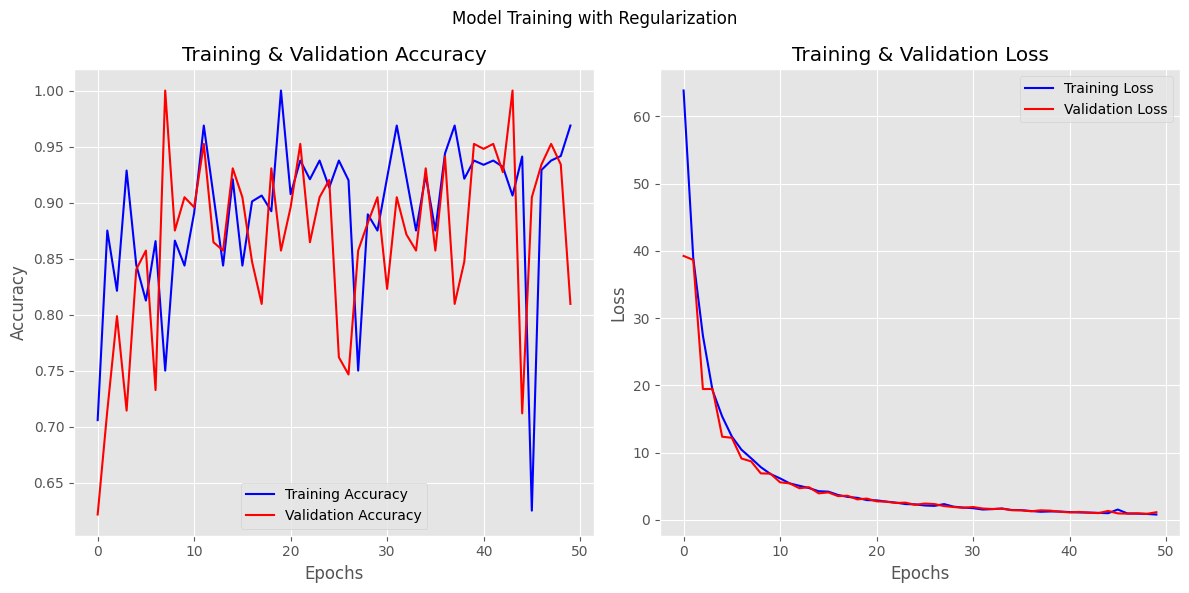

In [ ]:
# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Model Training with Regularization", fontsize=12)

# Accuracy plot
ax1.plot(history.history['accuracy'], color='b', label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], color='r', label='Validation Accuracy')
ax1.set_title('Training & Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], color='b', label='Training Loss')
ax2.plot(history.history['val_loss'], color='r', label='Validation Loss')
ax2.set_title('Training & Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig("regularized_training_validation_performance.jpeg", format='jpeg', dpi=100, bbox_inches='tight')
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 377ms/step


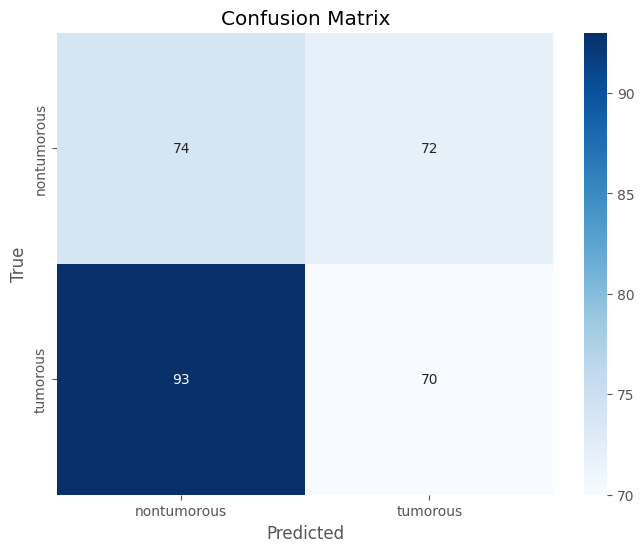

Classification Report:
              precision    recall  f1-score   support

 nontumorous       0.44      0.51      0.47       146
    tumorous       0.49      0.43      0.46       163

    accuracy                           0.47       309
   macro avg       0.47      0.47      0.47       309
weighted avg       0.47      0.47      0.47       309



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the validation data
valid_generator.reset()  # Reset the generator to start predictions from the first batch
predictions = model_01.predict(valid_generator, steps=valid_generator.samples // valid_generator.batch_size + 1)
predicted_classes = np.argmax(predictions, axis=1)  # Get the predicted class indices

# Get the true labels
true_classes = valid_generator.classes  # Actual class labels from the generator
class_labels = list(valid_generator.class_indices.keys())  # Class names (label to class mapping)

# Confusion Matrix
conf_matrix = confusion_matrix(true_classes[:len(predicted_classes)], predicted_classes)  # Ensure lengths match

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(true_classes[:len(predicted_classes)], predicted_classes, target_names=class_labels))


In [ ]:
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load the VGG19 model with pre-trained weights
base_model = VGG19(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze all layers in the base model initially
for layer in base_model.layers:
    layer.trainable = False

# Build the custom model
x = base_model.output
flat = Flatten()(x)

# Add dense layers with L2 regularization and increased dropout
class_1 = Dense(4608, activation='relu', kernel_regularizer=l2(0.01))(flat)
drop_out = Dropout(0.5)(class_1)  # Increased dropout
class_2 = Dense(1152, activation='relu', kernel_regularizer=l2(0.01))(drop_out)
output = Dense(2, activation='softmax')(class_2)

model_01 = Model(base_model.input, output)
model_01.summary()

# Compile the model (initial frozen base layers)
model_01.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),  # Low learning rate for initial training
    metrics=['accuracy']
)

# Define callbacks
es = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-7
)  # Dynamically reduce learning rate

# Train the frozen model
history = model_01.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,  # Train frozen layers for fewer epochs
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // valid_generator.batch_size,
    callbacks=[es, reduce_lr],
)

# Fine-tune the model: unfreeze the top layers of VGG19
for layer in base_model.layers[-5:]:  # Unfreeze last 5 layers
    layer.trainable = True

# Compile the model again with a smaller learning rate
model_01.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),  # Smaller learning rate for fine-tuning
    metrics=['accuracy']
)

# Fine-tune the model
fine_tune_history = model_01.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=30,  # Additional epochs for fine-tuning
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // valid_generator.batch_size,
    callbacks=[es, reduce_lr],
)



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 140,946,370 (537.67 MB)

 Trainable params: 120,921,986 (461.28 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 399ms/step - accuracy: 0.6911 - loss: 78.8563 - val_accuracy: 0.7014 - val_loss: 39.0972 - learning_rate: 1.0000e-04
Epoch 2/20
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7500 - loss: 38.9795

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7500 - loss: 38.9795 - val_accuracy: 0.8095 - val_loss: 38.5321 - learning_rate: 1.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 350ms/step - accuracy: 0.8046 - loss: 32.2935 - val_accuracy: 0.7986 - val_loss: 19.5133 - learning_rate: 1.0000e-04
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - accuracy: 0.8438 - loss: 19.3630 - val_accuracy: 0.5714 - val_loss: 19.7632 - learning_rate: 1.0000e-04
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 348ms/step - accuracy: 0.7868 - loss: 17.2804 - val_accuracy: 0.7569 - val_loss: 12.5658 - learning_rate: 1.0000e-04
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8125 - loss: 12.4055 - val_accuracy: 0.7143 - val_loss: 12.4165 - learning_rate: 1.0000e-04
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 352ms/step - accuracy: 0.8493 - loss: 11.3559 - val_accuracy: 0.8576 - val_loss: 8.9825 - learning_rate: 1.0000e-04
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - accuracy: 

In [ ]:
# Evaluate the fine-tuned model
val_loss, val_accuracy = model_01.evaluate(valid_generator, verbose=1)
print(f"\nFine-Tuned Validation Loss: {val_loss}")
print(f"Fine-Tuned Validation Accuracy: {val_accuracy}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - accuracy: 0.9931 - loss: 1.0958

Fine-Tuned Validation Loss: 1.1104707717895508
Fine-Tuned Validation Accuracy: 0.9902912378311157


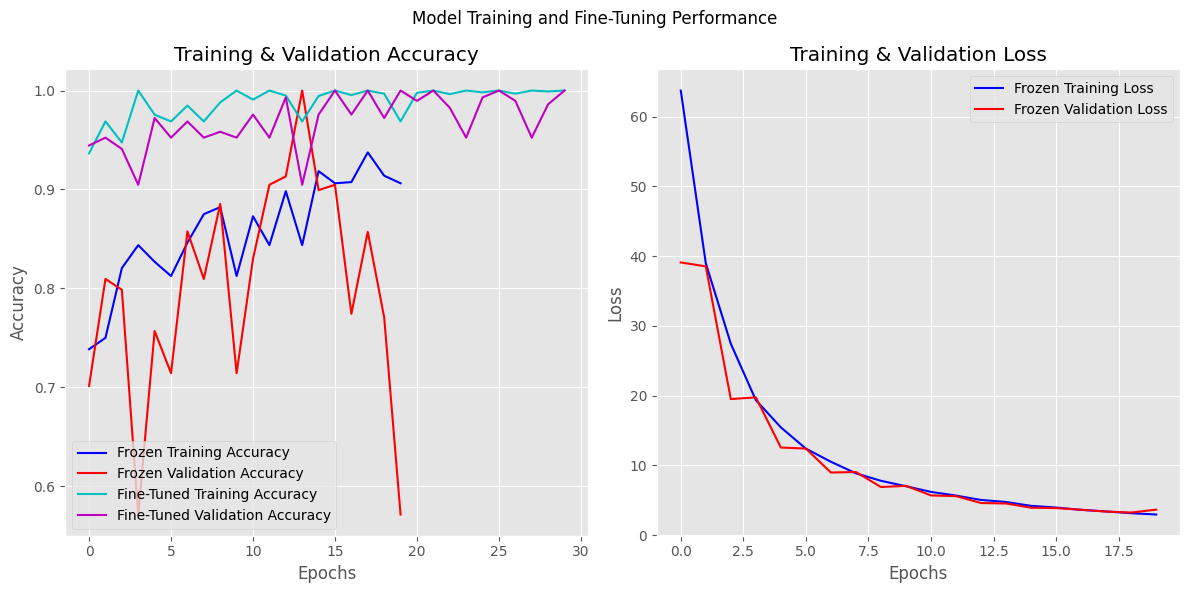

In [ ]:

  # Plot the training performance
  import matplotlib.pyplot as plt

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
  fig.suptitle("Model Training and Fine-Tuning Performance", fontsize=12)

  # Accuracy plot
  ax1.plot(history.history['accuracy'], color='b', label='Frozen Training Accuracy')
  ax1.plot(history.history['val_accuracy'], color='r', label='Frozen Validation Accuracy')
  ax1.plot(fine_tune_history.history['accuracy'], color='c', label='Fine-Tuned Training Accuracy')
  ax1.plot(fine_tune_history.history['val_accuracy'], color='m', label='Fine-Tuned Validation Accuracy')
  ax1.set_title('Training & Validation Accuracy')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Accuracy')
  ax1.legend()

  # Loss plot
  ax2.plot(history.history['loss'], color='b', label='Frozen Training Loss')
  ax2.plot(history.history['val_loss'], color='r', label='Frozen Validation Loss')
  # ax2.plot(fine_tune_history.history['loss'], color='c', label='Fine-Tuned Training Loss')
  # ax2.plot(fine_tune_history.history['val_loss'], color='m', label='Fine-Tuned Validation Loss')
  ax2.set_title('Training & Validation Loss')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Loss')
  ax2.legend()

  plt.tight_layout()
  plt.savefig("fine_tuning_training_validation_performance.jpeg", format='jpeg', dpi=100, bbox_inches='tight')
  plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 354ms/step

--- Fine-tuned Model Summary ---
Validation Loss: 1.1104707717895508
Validation Accuracy: 0.9902912378311157


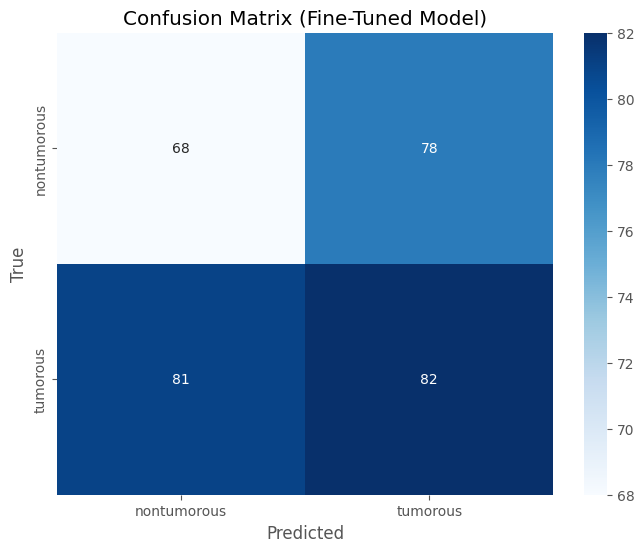


Classification Report (Fine-Tuned Model):
              precision    recall  f1-score   support

 nontumorous       0.46      0.47      0.46       146
    tumorous       0.51      0.50      0.51       163

    accuracy                           0.49       309
   macro avg       0.48      0.48      0.48       309
weighted avg       0.49      0.49      0.49       309



In [ ]:
# prompt: make sumary of all fintune results and confusio matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Assuming 'history', 'fine_tune_history', 'valid_generator', and 'model_01' are defined from the previous code

# ... (Your existing code) ...

# Predict on the validation data for the fine-tuned model
valid_generator.reset()
predictions_fine_tuned = model_01.predict(valid_generator, steps=valid_generator.samples // valid_generator.batch_size + 1)
predicted_classes_fine_tuned = np.argmax(predictions_fine_tuned, axis=1)

# Get true classes (same as before)
true_classes = valid_generator.classes
class_labels = list(valid_generator.class_indices.keys())


# Summarize the results
print("\n--- Fine-tuned Model Summary ---")
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)


# Confusion Matrix for the fine-tuned model
conf_matrix_fine_tuned = confusion_matrix(true_classes[:len(predicted_classes_fine_tuned)], predicted_classes_fine_tuned)

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_fine_tuned, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix (Fine-Tuned Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report for the fine-tuned model
print("\nClassification Report (Fine-Tuned Model):")
print(classification_report(true_classes[:len(predicted_classes_fine_tuned)], predicted_classes_fine_tuned, target_names=class_labels))

In [ ]:

from sklearn.metrics import f1_score

# ... (Your existing code) ...

# Predict on the validation data for the fine-tuned model
valid_generator.reset()
predictions_fine_tuned = model_01.predict(valid_generator, steps=valid_generator.samples // valid_generator.batch_size + 1)
predicted_classes_fine_tuned = np.argmax(predictions_fine_tuned, axis=1)

# Get true classes (same as before)
true_classes = valid_generator.classes

# Calculate F1-score
f1 = f1_score(true_classes[:len(predicted_classes_fine_tuned)], predicted_classes_fine_tuned, average='weighted') # Use 'weighted' for multi-class


# Summarize the results
print("\n--- Fine-tuned Model Summary ---")
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)
print("Validation F1-score:", f1)


# ... (rest of your code)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step

--- Fine-tuned Model Summary ---
Validation Loss: 1.1104707717895508
Validation Accuracy: 0.9902912378311157
Validation F1-score: 0.4986029817208229


In [ ]:

from sklearn.metrics import f1_score

# ... (Your existing code) ...

# Assuming 'true_classes' and 'predicted_classes_fine_tuned' are defined

# Calculate the F1-score for the fine-tuned model
f1 = f1_score(true_classes[:len(predicted_classes_fine_tuned)], predicted_classes_fine_tuned, average='weighted')  # Use 'weighted' for multi-class

print(f"\nF1-score (Fine-tuned Model): {f1}")

# Evaluate the fine-tuned model on the test set
test_loss, test_accuracy = model_01.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


F1-score (Fine-tuned Model): 0.4954210678144827


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 889ms/step - accuracy: 0.9936 - loss: 1.1019

Test Loss: 1.1179428100585938
Test Accuracy: 0.9870967864990234
